In [318]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from helper import find_inbus_contour
import matplotlib.patches as patches
from matplotlib.patches import Circle
import math


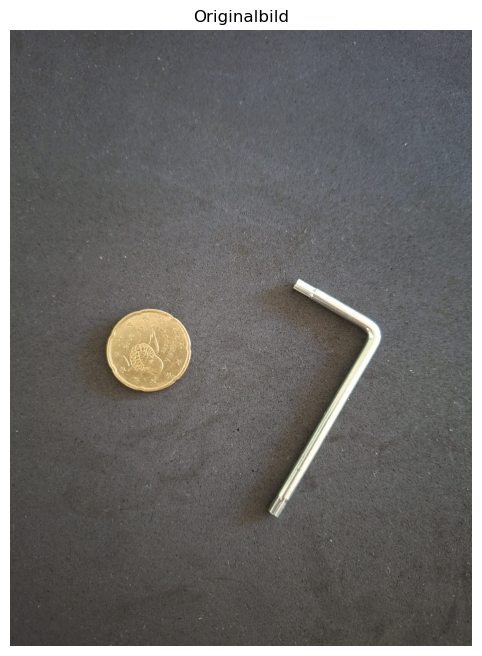

In [319]:
# ============================================================
# 1. Bild laden und anzeigen
# ============================================================
img = cv2.imread("bilder/image_4.jpg")

# OpenCV lädt in BGR -> für matplotlib RGB umwandeln
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8,8))
plt.imshow(img_rgb)
plt.title("Originalbild")
plt.axis("off")
plt.show()

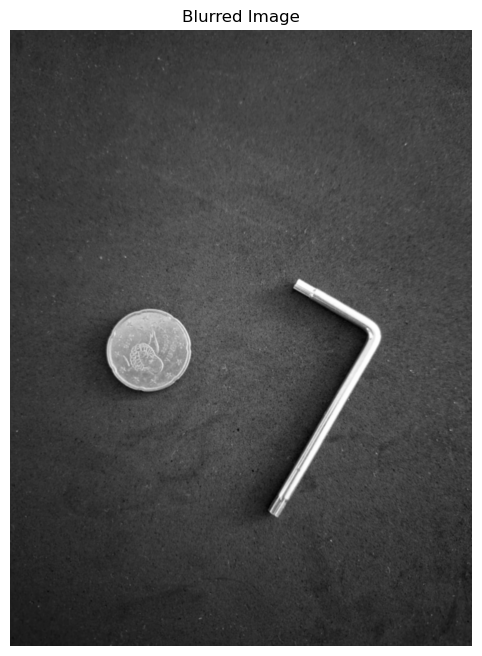

In [320]:
# ============================================================
# 2. Vorverarbeitung des Bildes
# Ziel: Vorbereitung für weitere CV-Schritte durch
# - Graustufen-Konvertierung
# - Rauschreduzierung mittels Gaussian Blur
# ============================================================

# Bild in Graustufen umwandeln
imgInGrey = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Gaussian Blur
imgBlurred = cv2.GaussianBlur(imgInGrey, (7, 7), 0)

plt.figure(figsize=(8,8))
plt.imshow(imgBlurred, cmap="gray")
plt.title("Blurred Image")
plt.axis("off")
plt.show()

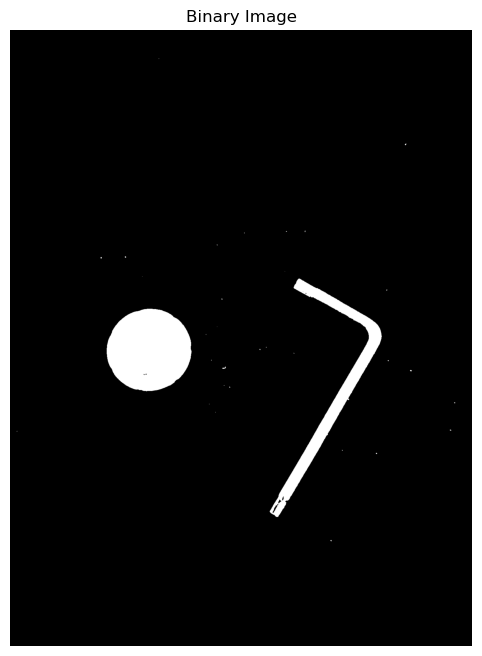

In [321]:
# ============================================================
# 3. Binarisierung
# Otsu-Verfahren bestimmt den optimalen Schwellenwert automatisch
# ============================================================
_, imgBinary = cv2.threshold(imgBlurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Binäres Bild anzeigen
plt.figure(figsize=(8,8))
plt.imshow(imgBinary, cmap="gray")
plt.title("Binary Image")
plt.axis("off")
plt.show()

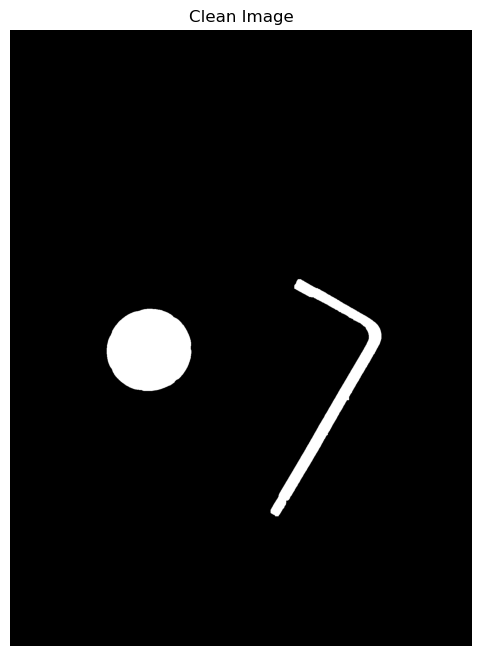

In [322]:
# ============================================================
# 4. Morphologische Operationen zur Bildverbesserung
# Ziel: kleine Störungen entfernen und Löcher in Objekten schließen
# ============================================================

kernel = np.ones((5, 5), np.uint8)

# CLOSE-Operation: Füllt kleine Löcher innerhalb der Objekte
imgClean = cv2.morphologyEx(
    imgBinary,
    cv2.MORPH_CLOSE,
    kernel,
    iterations=2
)

# OPEN-Operation: Entfernt kleine Störpixel / Rauschen im Hintergrund
imgClean = cv2.morphologyEx(
    imgClean,
    cv2.MORPH_OPEN,
    kernel,
    iterations=2
)

# Ergebnis der Bildbereinigung anzeigen
plt.figure(figsize=(8,8))
plt.imshow(imgClean, cmap="gray")
plt.title("Clean Image")
plt.axis("off")
plt.show()

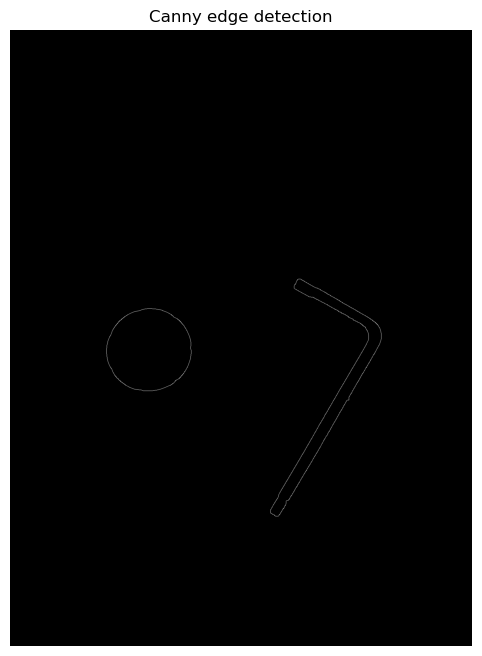

In [323]:
# ============================================================
# 5. Kantenerkennung mit Canny Edge Detection
# Ziel: Wichtige Objektkanten im Bild hervorheben, um spätere Kontur- und Formanalyse zu ermöglichen
# ============================================================
edges = cv2.Canny(imgClean, 50, 150)
plt.figure(figsize=(8,8))
plt.imshow(edges, cmap="gray")
plt.title("Canny edge detection")
plt.axis("off")
plt.show()

In [324]:
######################################
######################################
# HIER ENDET DIE BILDBEARBEITUNGSPHASE
######################################
######################################

Anzahl Konturen: 2


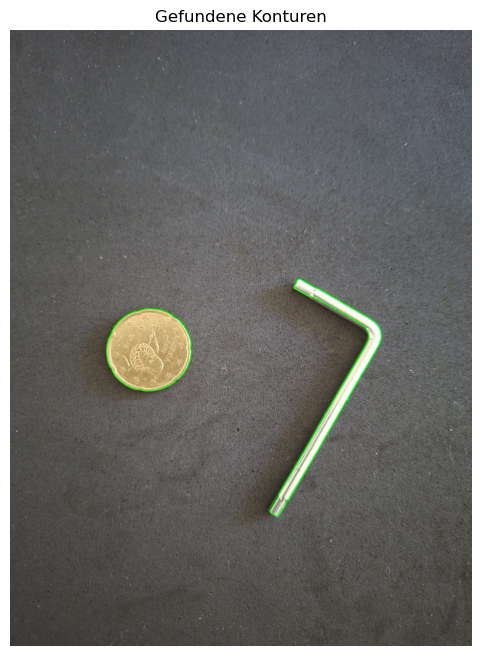

In [325]:
# ============================================================
# 6. Konturen im bereinigten Bild finden
# Ziel: Alle äußeren Objektkonturen extrahieren, um mögliche Bauteile (Münze, Inbus etc.) zu analysieren
# ============================================================

contours, _ = cv2.findContours(
    imgClean,
    cv2.RETR_EXTERNAL,  # nur äußere Konturen erkennen
    cv2.CHAIN_APPROX_SIMPLE  # speichert nur wichtige Konturpunkte
)

print("Anzahl Konturen:", len(contours))

# Alle Konturen im Bild zeichnen
contour_debug = img.copy()
cv2.drawContours(
    contour_debug,
    contours,
    -1,
    (0, 255, 0),
    2
)


# Ergebnis anzeigen
plt.figure(figsize=(8,8))
plt.imshow(cv2.cvtColor(contour_debug, cv2.COLOR_BGR2RGB))
plt.title("Gefundene Konturen")
plt.axis("off")
plt.show()

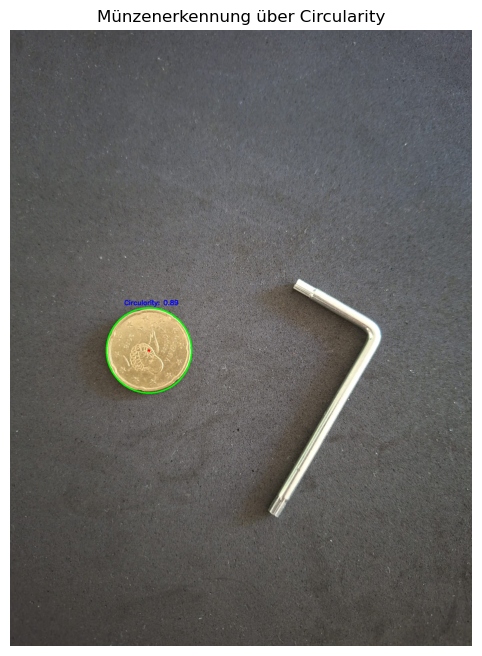

In [326]:
# ============================================================
# 7. Münze über Konturen erkennen (unser Kalibrierungsobjekt)
# Ziel: Die kreisförmigste Kontur finden, um sie als Referenz für die Pixel-zu-mm-Kalibrierung zu nutzen
# ============================================================

coin_contour = None
best_circularity = 0

for c in contours:

    # Fläche der Kontur berechnen
    area = cv2.contourArea(c)

    # Sehr kleine Konturen ignorieren
    if area < 200:
        continue

     # Umfang der Kontur berechnen
    perimeter = cv2.arcLength(c, True)

    # Division durch 0 vermeiden
    if perimeter == 0:
        continue

    # Circularity berechnen
    # Formel: (4 * π * Fläche) / Umfang²
    circularity = (4 * np.pi * area) / (perimeter ** 2)

    # Prüfen ob Kontur kreisförmig ist
    # Wert nahe 1 -> sehr kreisförmig
    # Wert kleiner -> eher unregelmäßige Form
    if circularity > best_circularity:
        best_circularity = circularity
        coin_contour = c

# Prüfen ob eine passende Kontur gefunden wurde
if coin_contour is None:
    print("Keine Münze gefunden!")
    exit()


# Minimalen Umkreis der Münze berechnen
(x, y), radius = cv2.minEnclosingCircle(coin_contour)

x = int(x)
y = int(y)
radius = int(radius)

# Münze visualisieren
coin_debug = img.copy()

cv2.circle(
    coin_debug,
    (x, y),
    radius,
    (0, 255, 0),
    3
)

cv2.circle(
    coin_debug,
    (x, y),
    4,
    (0, 0, 255),
    -1
)

# Circularity anzeigen
cv2.putText(
    coin_debug,
    f"Circularity: {best_circularity:.2f}",
    (x - 80, y - radius - 10),
    cv2.FONT_HERSHEY_SIMPLEX,
    0.7,
    (255, 0, 0),
    2
)

# Ergebnis anzeigen
plt.figure(figsize=(8,8))

plt.imshow(cv2.cvtColor(coin_debug, cv2.COLOR_BGR2RGB))
plt.title("Münzenerkennung über Circularity")

plt.axis("off")
plt.show()

In [327]:
# ============================================================
# 8. Pixel pro mm berechnen
# Ziel: Maßstab zwischen Bildpixeln und realer Größe bestimmen
# ============================================================

# Reeller Durchmesser der Referenzmünze
COIN_DIAMETER_MM = 30 # 20-Cent-Münze

# Durchmesser der Münze im Bild berechnen
coin_diameter_pixels = radius * 2

# Pixel pro Millimeter berechnen
pixels_per_mm = coin_diameter_pixels / COIN_DIAMETER_MM

print(f"Pixel pro mm: {pixels_per_mm:.2f}")

Pixel pro mm: 9.20


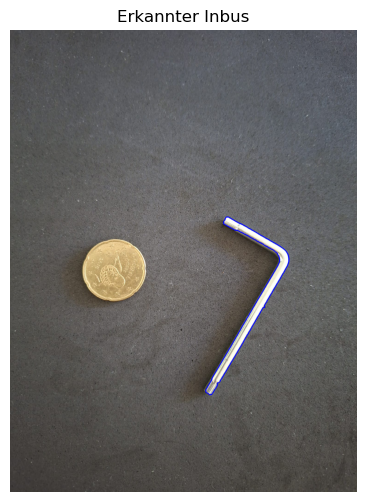

In [328]:
# ============================================================
# 9. Inbus-Kontur finden
# Ziel: Größte Kontur auswählen, die NICHT die Münze ist
# ============================================================

inbus_contour = None
max_area = 0

for c in contours:

    # Fläche der Kontur berechnen
    area = cv2.contourArea(c)

    # Kleine Konturen ignorieren
    if area < 500:
        continue

    # Bounding Box der Kontur berechnen und daraus den Mittelpunkt bestimmen
    x_c, y_c, w, h = cv2.boundingRect(c)

    center_x = x_c + w // 2
    center_y = y_c + h // 2

    # Abstand zwischen Konturmittelpunkt und Münzmittelpunkt berechnen
    distance = np.sqrt((center_x - x)**2 + (center_y - y)**2)

    # Falls die Kontur innerhalb der Münze liegt, wird übersprungen
    if distance < radius:
        continue

    # Größte verbleibende Kontur
    # Annahme: Der Inbus ist das größte Objekt außer der Münze
    if area > max_area:
        max_area = area
        inbus_contour = c

if inbus_contour is None:
    print("Kein Inbus gefunden!")
    exit()


inbus_debug = img.copy()

# Erkannte Inbus-Kontur visualisieren
cv2.drawContours(
    inbus_debug,
    [inbus_contour],
    -1,
    (255,0,0),
    3
)

# Ergebnis anzeigen
plt.figure(figsize=(8,6))
plt.imshow(cv2.cvtColor(inbus_debug, cv2.COLOR_BGR2RGB))
plt.title("Erkannter Inbus")
plt.axis("off")
plt.show()

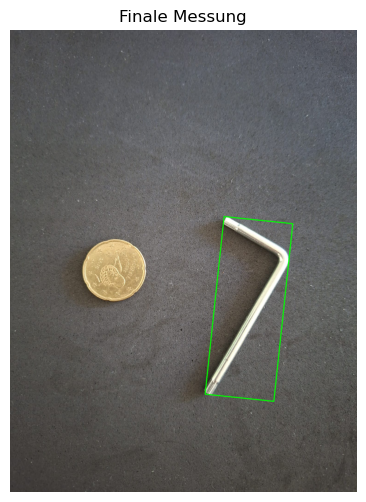

In [329]:
# ============================================================
# 10. Rotierte Bounding Box berechnen
# Ziel: Kleinste gedrehte Rechteckbox bestimmen, die den Inbus vollständig umschließt
# ============================================================

rect = cv2.minAreaRect(inbus_contour)

(center), (width, height), angle = rect

# Längere Seite = Höhe
if width > height:
    width, height = height, width

# Eckpunkte berechnen
box = cv2.boxPoints(rect)
box = np.int32(box)

# Bounding Box zeichnen
final_debug = img.copy()

cv2.drawContours(
    final_debug,
    [box],
    0,
    (0,255,0),
    3
)

# Ergebnis zeigen
plt.figure(figsize=(8,6))
plt.imshow(cv2.cvtColor(final_debug, cv2.COLOR_BGR2RGB))
plt.title("Finale Messung")
plt.axis("off")
plt.show()

Breite des Inbusschlüssels: 32.46 mm
Länge des Inbusschlüssels: 84.07 mm


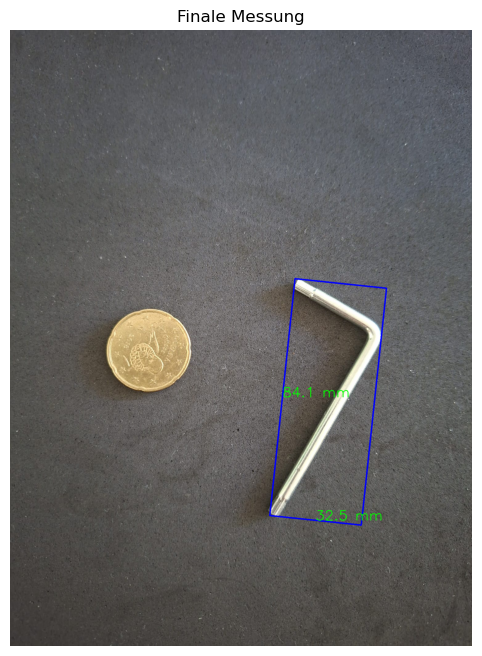

In [330]:
# ============================================================
# 11. Größe des Inbusschlüssels in mm berechnen
# ============================================================

width_mm = width / pixels_per_mm
height_mm = height / pixels_per_mm

print(f"Breite des Inbusschlüssels: {width_mm:.2f} mm")
print(f"Länge des Inbusschlüssels: {height_mm:.2f} mm")

# Finale Visualisierung
final_img = img.copy()

# Bounding Box zeichnen
cv2.drawContours(
    final_img,
    [box],
    0,
    (255, 0, 0),
    3
)

# Eckpunkte der Bounding Box
p1, p2, p3, p4 = box

# Mittelpunkt der langen Seite berechnen
long_mid = (
    (p2[0] + p3[0]) // 2,
    (p2[1] + p3[1]) // 2
)

# Mittelpunkt der kurzen Seite berechnen
short_mid = (
    (p1[0] + p2[0]) // 2,
    (p1[1] + p2[1]) // 2
)

# Länge direkt am Objekt anzeigen
cv2.putText(
    final_img,
    f"{height_mm:.1f} mm",
    long_mid,
    cv2.FONT_HERSHEY_SIMPLEX,
    1.5,
    (0, 255, 0),
    2
)

# Breite direkt am Objekt anzeigen
cv2.putText(
    final_img,
    f"{width_mm:.1f} mm",
    short_mid,
    cv2.FONT_HERSHEY_SIMPLEX,
    1.5,
    (0, 255, 0),
    2
)

# Ergebnis anzeigen
plt.figure(figsize=(8,8))
plt.imshow(cv2.cvtColor(final_img, cv2.COLOR_BGR2RGB))
plt.title("Finale Messung")
plt.axis("off")
plt.show()

11


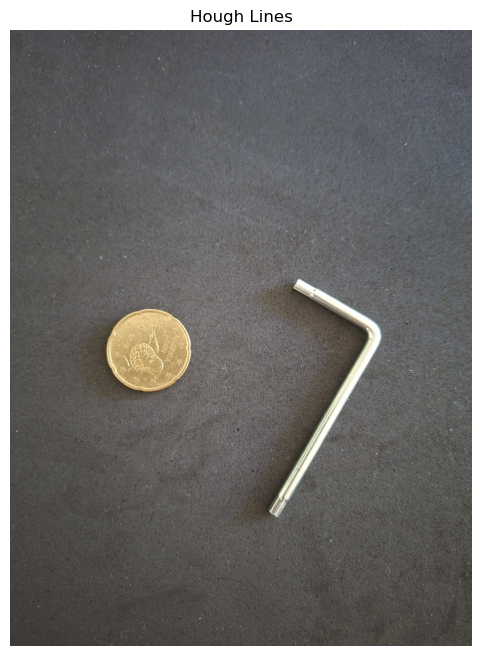

In [331]:
# ============================================================
# 12. Alternative Methode: Hough Line Transform
# Ziel: Gerade Linien im Bild erkennen (Kanten des Inbusschlüssels)
# ============================================================
lines = cv2.HoughLinesP(
    edges,
    1,
    np.pi / 180,
    threshold=50,
    maxLineGap=200
)

debug = img.copy()

print(len(lines))

for line in lines:
    x1, y1, x2, y2 = line[0]
    cv2.line(img, (x1, y1), (x2, y2), (0, 255, 0), thickness=3)
# OpenCV BGR -> matplotlib RGB
debug_rgb = cv2.cvtColor(debug, cv2.COLOR_BGR2RGB)

# Bild anzeigen
plt.figure(figsize=(8,8))
plt.imshow(debug_rgb)
plt.title("Hough Lines")
plt.axis("off")
plt.show()